# Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../')

In [3]:
from functions import Mchirp

In [4]:
plt.rcParams['font.family']      = 'serif'
plt.rcParams['font.serif']       = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'  # <--- default: dejavusans

In [5]:
# System mass function
def Msys(M1, M2):
    return M1 + M2

# Chirp Mass

In [6]:
# Choose the mass range for (identical) stars
M_lower = 0.2
M_upper = 5
M1vals = np.linspace(M_lower, M_upper, 1000)
M2vals = np.linspace(M_lower, M_upper, 1000)

# Calculate the contour grid
MM2vals, MM1vals = np.meshgrid(M2vals, M1vals)
MMcvals = Mchirp(MM1vals, MM2vals)

# Plot only contours where M1 >= M2
mask = MM1vals >= MM2vals
MMcvals = np.where(mask, MMcvals, np.nan)

/var/folders/66/47rx8tnd05173x195n9trmvr0000gp/T/ipykernel_60643/4274816105.py:28: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x12d6ea2d0>' will be ignored
  axcontourf.set_rasterized(True)


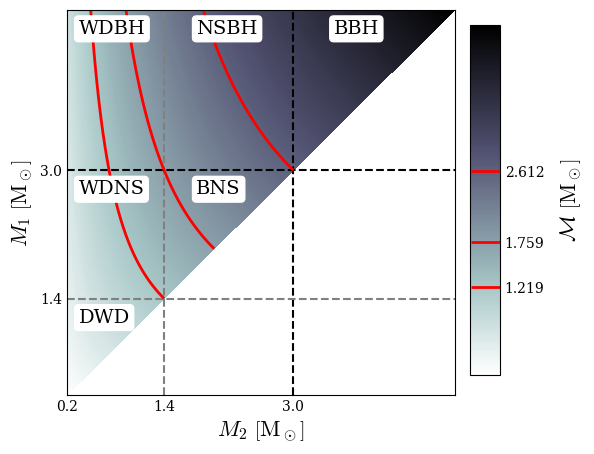

In [7]:
fig, ax = plt.subplots(1,1,figsize=(5,5))

axcontourf = ax.contourf(MM2vals, MM1vals, MMcvals, 400, cmap='bone_r')

cbar_ax = fig.add_axes([0.93, 0.15, 0.06, 0.7])
cbar = fig.colorbar(axcontourf, cax=cbar_ax, ticks=[Mchirp(1.4,1.4),Mchirp(3,1.4),Mchirp(3,3)])
cbar.set_label(r'$\mathcal{M} \ \left[\text{M}_\odot\right]$', labelpad=10, fontsize=16)
cbar.ax.tick_params(color='red', direction='in', width=2, length=21)

ax.axhline(3,   linestyle='--', color='k'),    ax.axvline(3,   linestyle='--', color='k')
ax.axhline(1.4, linestyle='--', color='gray'), ax.axvline(1.4, linestyle='--', color='gray')

ax.contour(MM2vals, MM1vals, MMcvals, [Mchirp(1.4,1.4),Mchirp(3,1.4),Mchirp(3,3)], colors='r', linestyles='solid', linewidths=2)

ax.set_yticks([1.4,3])
ax.set_xticks([M_lower,1.4,3])
ax.tick_params(length=0)

bboxdict = dict(alpha=1,color='white',boxstyle='round',pad=0.2)
ax.text(.34, 4.7, "WDBH", size=14, bbox=bboxdict), ax.text(1.8, 4.7, "NSBH", size=14, bbox=bboxdict), ax.text(3.5, 4.7, "BBH", size=14, bbox=bboxdict)
ax.text(.34, 2.7, "WDNS", size=14, bbox=bboxdict), ax.text(1.8, 2.7, "BNS",  size=14, bbox=bboxdict)
ax.text(.34, 1.1, "DWD",  size=14, bbox=bboxdict)

ax.set_xlabel(r'$M_2 \ \left[\text{M}_\odot\right]$', fontsize=16), ax.set_ylabel(r'$M_1 \ \left[\text{M}_\odot\right]$', fontsize=16), 

# Rasterize the contourfs, to reduce the PDF file size significantly!
# NOTE: it may output a "UserWarning" - I don't know why, but this line still works (verified by opening the file in Inkscape)
axcontourf.set_rasterized(True)

plt.show()
# plt.savefig('./binary_types_chirpmass.pdf', bbox_inches='tight')

# System Mass

In [8]:
# Choose the mass range for (identical) stars
M_lower = 0.2
M_upper = 5
M1vals = np.linspace(M_lower, M_upper, 1000)
M2vals = np.linspace(M_lower, M_upper, 1000)

# Calculate the contour grid
MM2vals, MM1vals = np.meshgrid(M2vals, M1vals)
MMsvals = Msys(MM1vals, MM2vals)

mask = MM1vals >= MM2vals
MMsvals = np.where(mask, MMsvals, np.nan)

/var/folders/66/47rx8tnd05173x195n9trmvr0000gp/T/ipykernel_5061/3911476246.py:28: UserWarning: Rasterization of '<matplotlib.contour.QuadContourSet object at 0x11d7069f0>' will be ignored
  axcontourf.set_rasterized(True)


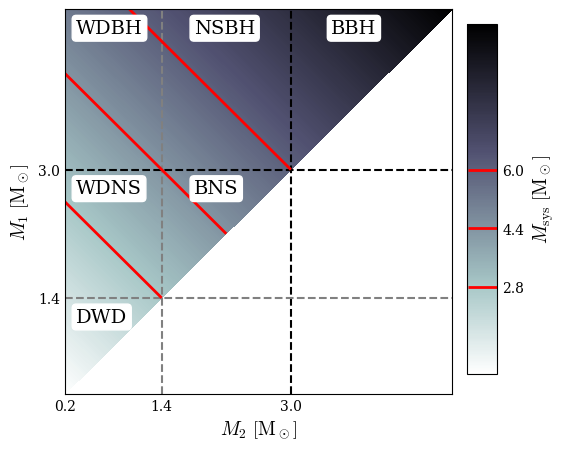

In [9]:
fig, ax = plt.subplots(1,1,figsize=(5,5))

axcontourf = ax.contourf(MM2vals, MM1vals, MMsvals, 400, cmap='bone_r')

cbar_ax = fig.add_axes([0.93, 0.15, 0.06, 0.7])
cbar = fig.colorbar(axcontourf, cax=cbar_ax, ticks=[Msys(1.4,1.4),Msys(3,1.4),Msys(3,3)])# ticks=np.arange(0,11,2))
cbar.set_label(r'$M_\mathrm{sys} \ \left[\text{M}_\odot\right]$', labelpad=5, fontsize=14)
cbar.ax.tick_params(color='red', direction='in', width=2, length=21)

ax.axhline(3,   linestyle='--', color='k'),    ax.axvline(3,   linestyle='--', color='k')
ax.axhline(1.4, linestyle='--', color='gray'), ax.axvline(1.4, linestyle='--', color='gray')

ax.contour(MM2vals, MM1vals, MMsvals, [Msys(1.4,1.4),Msys(3,1.4),Msys(3,3)], colors='r', linestyles='solid', linewidths=2)

ax.set_yticks([1.4,3])
ax.set_xticks([M_lower,1.4,3])
ax.tick_params(length=0)

bboxdict = dict(alpha=1,color='white',boxstyle='round',pad=0.2)
ax.text(.34, 4.7, "WDBH", size=14, bbox=bboxdict), ax.text(1.8, 4.7, "NSBH", size=14, bbox=bboxdict), ax.text(3.5, 4.7, "BBH", size=14, bbox=bboxdict)
ax.text(.34, 2.7, "WDNS", size=14, bbox=bboxdict), ax.text(1.8, 2.7, "BNS",  size=14, bbox=bboxdict)
ax.text(.34, 1.1, "DWD",  size=14, bbox=bboxdict)

ax.set_xlabel(r'$M_2 \ \left[\text{M}_\odot\right]$', fontsize=14), ax.set_ylabel(r'$M_1 \ \left[\text{M}_\odot\right]$', fontsize=14), 

# Rasterize the contourfs, to reduce the PDF file size significantly!
# NOTE: it may output a "UserWarning" - I don't know why, but this line still works (verified by opening the file in Inkscape)
axcontourf.set_rasterized(True)

plt.show()
# plt.savefig('./binary_types_systemmass.pdf', bbox_inches='tight')